<a href="https://colab.research.google.com/github/ssabouni/DentalFaultDetection/blob/main/model_testing_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries,
import os
import json
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import Counter
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence

In [2]:
# mount Drive and define model_path.


from google.colab import drive
drive.mount("/content/drive")

# Point to the best checkpoint model file
model_path = "/content/drive/MyDrive/dental-project/models/dental_fault_best.h5"

Mounted at /content/drive


In [3]:
# Load train_annotations / val_annotations and create train_generator / val_generator

# Define paths for train, valid, and test datasets
base_dir = "/content/drive/MyDrive/dental-project/data"
train_image_dir = os.path.join(base_dir, "train")
valid_image_dir = os.path.join(base_dir, "valid")
subsets = ["train", "valid", "test"]

train_annotation_file = os.path.join(train_image_dir, "_annotations.coco.json")
val_annotation_file = os.path.join(valid_image_dir, "_annotations.coco.json")

# Load annotations
def load_annotations(annotation_file):
    with open(annotation_file, 'r') as f:
        return json.load(f)

train_annotations = load_annotations(train_annotation_file)
val_annotations = load_annotations(val_annotation_file)

In [4]:
class ObjectDetectionDataGenerator(Sequence):
    def __init__(self, annotations, image_dir, batch_size=32, shuffle=True, max_objects=8):
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.max_objects = max_objects

        self.img_id_to_filename = {img['id']: img['file_name'] for img in annotations['images']}
        self.img_id_to_size = {img['id']: (img['width'], img['height']) for img in annotations['images']}
        self.annotations_by_image = {}

        for ann in annotations['annotations']:
            image_id = ann['image_id']
            if image_id not in self.annotations_by_image:
                self.annotations_by_image[image_id] = []
            self.annotations_by_image[image_id].append(ann)

        self.image_ids = list(self.annotations_by_image.keys())
        if self.shuffle:
            np.random.shuffle(self.image_ids)

    def __getitem__(self, index):
        batch_ids = self.image_ids[index * self.batch_size:(index + 1) * self.batch_size]
        images, boxes, classes = [], [], []

        for image_id in batch_ids:
            image_path = os.path.join(self.image_dir, self.img_id_to_filename[image_id])
            image = cv2.imread(image_path)

            if image is None:
                print(f"Warning: Skipping missing image {image_path}")
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = image.astype(np.float32)
            images.append(image)

            anns = self.annotations_by_image[image_id]

            b = np.array([ann['bbox'] for ann in anns], dtype=np.float32)
            c = np.ones(len(anns), dtype=np.int32)

            # Normalize bbox from pixels to 0-1 using original image size
            img_w, img_h = self.img_id_to_size[image_id]
            if len(b) > 0:
                b[:, 0] = b[:, 0] / img_w   # x
                b[:, 1] = b[:, 1] / img_h   # y
                b[:, 2] = b[:, 2] / img_w   # width
                b[:, 3] = b[:, 3] / img_h   # height

            if len(b) > self.max_objects:
                b = b[:self.max_objects]
                c = c[:self.max_objects]

            b = np.pad(
                b,
                ((0, max(0, self.max_objects - len(b))), (0, 0)),
                mode='constant',
                constant_values=0
            )
            c = np.pad(
                c,
                (0, max(0, self.max_objects - len(c))),
                mode='constant',
                constant_values=0
            )

            boxes.append(b)
            classes.append(c)

        return np.array(images), (np.array(boxes), np.array(classes))

    def __len__(self):
        return int(np.ceil(len(self.image_ids) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.image_ids)

# Create training and validation generators
train_generator = ObjectDetectionDataGenerator(train_annotations, train_image_dir, max_objects=8)
val_generator = ObjectDetectionDataGenerator(val_annotations, valid_image_dir, max_objects=8)

In [5]:
# Test the generator manually
import os

print(f"Checking images in: {valid_image_dir}")
sample_ann = val_annotations['images'][0]
sample_path = os.path.join(valid_image_dir, sample_ann['file_name'])

if os.path.exists(sample_path):
    print("Success: Sample image found!")
else:
    print(f"Failure: Sample image NOT found at {sample_path}")
    # List a few files to debug the naming
    print("Files in directory include:", os.listdir(valid_image_dir)[:5])

Checking images in: /content/drive/MyDrive/dental-project/data/valid
Success: Sample image found!


In [21]:
#Load the saved model with load_model

# Load the saved model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "preprocess_input": preprocess_input
    },
    compile=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        'bbox': 'mse',
        'class': 'binary_crossentropy'
    },
    loss_weights={
        'bbox': 10.0,
        'class': 1.0
    },
    metrics={
        'bbox': ['mae'],
        'class': ['accuracy']
    }
)

test_results = model.evaluate(val_generator, verbose=1)

print("Raw test_results =", test_results)

print(f"Final Val Total Loss: {test_results[0]:.2f}")
print(f"Final Val BBox MSE: {test_results[1]:.2f}")
print(f"Final Val BBox MAE: {test_results[2]:.2f}px")
print(f"Final Val Class Loss: {test_results[3]:.2f}")
print(f"Final Val Class Acc: {test_results[4]:.1%}")

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y_true = []
for i in range(len(val_generator)):
    x_batch, y_batch = val_generator[i]
    y_true.extend(y_batch[1].reshape(-1))

y_true = np.array(y_true)

y_pred = model.predict(val_generator, verbose=1)
class_pred = y_pred[1].reshape(-1)
y_pred_label = (class_pred >= 0.5).astype(int)

precision = precision_score(y_true, y_pred_label, zero_division=0)
recall = recall_score(y_true, y_pred_label, zero_division=0)
f1 = f1_score(y_true, y_pred_label, zero_division=0)

print(f"Final Val Precision: {precision:.4f}")
print(f"Final Val Recall: {recall:.4f}")
print(f"Final Val F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_label, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - bbox_loss: 0.0235 - bbox_mae: 0.0885 - class_accuracy: 0.8155 - class_loss: 0.3997 - loss: 0.6347
Raw test_results = [0.6347483396530151, 0.02350926771759987, 0.39965566992759705, 0.08854858577251434, 0.8154761791229248]
Final Val Total Loss: 0.63
Final Val BBox MSE: 0.02
Final Val BBox MAE: 0.40px
Final Val Class Loss: 0.09
Final Val Class Acc: 81.5%
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Final Val Precision: 0.8448
Final Val Recall: 0.6901
Final Val F1 Score: 0.7597

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        97
           1       0.84      0.69      0.76        71

    accuracy                           0.82       168
   macro avg       0.82      0.80      0.80       168
weighted avg       0.82      0.82      0.81       168



In [17]:
def compute_iou(boxA, boxB):
    # box format: [x, y, w, h]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    boxA_area = max(0, boxA[2]) * max(0, boxA[3])
    boxB_area = max(0, boxB[2]) * max(0, boxB[3])

    union_area = boxA_area + boxB_area - inter_area
    if union_area <= 0:
        return 0.0

    return inter_area / union_area

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from matplotlib.patches import Rectangle

idx = 0
images, (true_boxes, true_classes) = val_generator[idx]

if hasattr(images, "numpy"):
    images_np = images.numpy()
else:
    images_np = images

# Predict
pred_boxes, pred_class_logits = model.predict(images_np, verbose=0)
pred_class_prob = tf.nn.sigmoid(pred_class_logits).numpy()
pred_class = (pred_class_prob > 0.5).astype(np.int32)

def draw_boxes(ax, img, boxes, classes, color, label_prefix="", scores=None, threshold=0.5):
    h, w = img.shape[:2]

    for i, (b, c) in enumerate(zip(boxes, classes)):
        c_val = c.numpy() if hasattr(c, "numpy") else c
        if c_val == 0:
            continue

        score_text = ""
        if scores is not None:
            s = scores[i]
            s_val = float(s.numpy()) if hasattr(s, "numpy") else float(s)
            if s_val < threshold:
                continue
            score_text = f" {s_val:.2f}"

        x, y, box_w, box_h = b * [w, h, w, h]


        rect = Rectangle((x, y), box_w, box_h, fill=False, color=color, linewidth=2)
        ax.add_patch(rect)
        ax.text(
            x,
            max(0, y - 5),
            f"{label_prefix}{i}{score_text}",
            color=color,
            fontsize=10,
            weight="bold"
        )

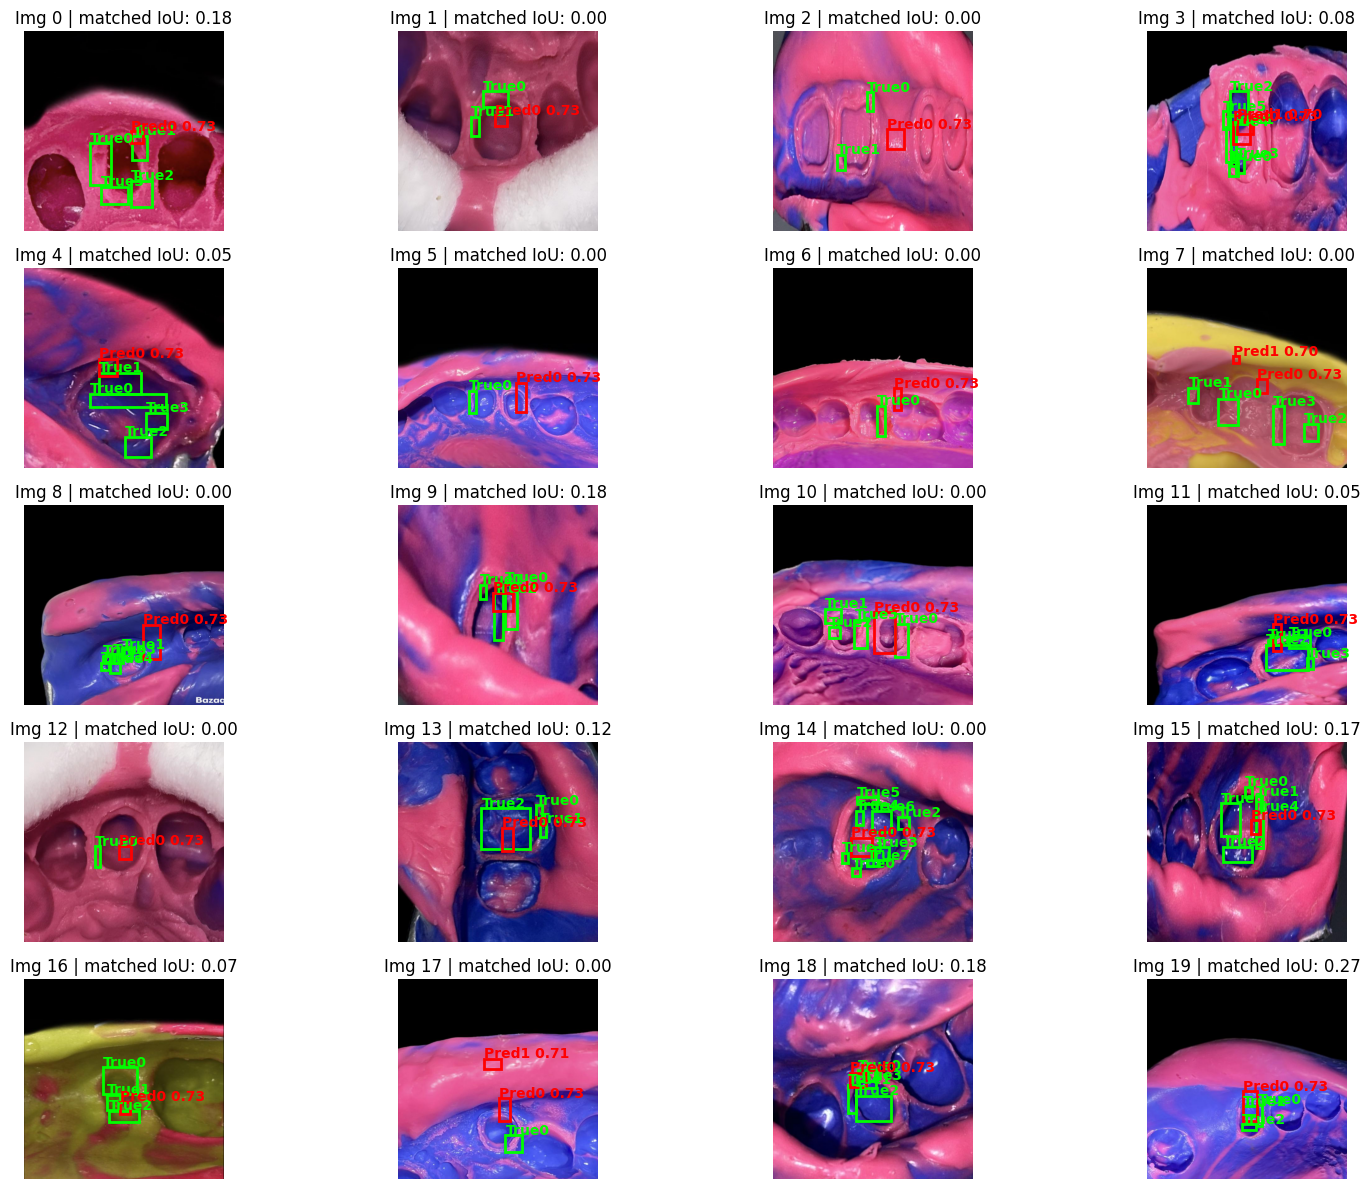

In [9]:
def compute_iou(boxA, boxB):
    # box format: [x, y, w, h]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    boxA_area = max(0, boxA[2]) * max(0, boxA[3])
    boxB_area = max(0, boxB[2]) * max(0, boxB[3])

    union_area = boxA_area + boxB_area - inter_area
    if union_area <= 0:
        return 0.0

    return inter_area / union_area

def get_matched_ious(img, true_boxes, true_classes, pred_boxes, pred_scores, score_thresh=0.7):
    h, w = img.shape[:2]
    scale = np.array([w, h, w, h])

    true_idx = [j for j in range(len(true_boxes)) if int(true_classes[j]) == 1]
    pred_idx = [j for j in range(len(pred_boxes)) if float(pred_scores[j]) >= score_thresh]

    if len(true_idx) == 0 or len(pred_idx) == 0:
        return []

    matches = []
    used_preds = set()

    for tj in true_idx:
        best_iou = 0
        best_pj = None

        true_px = true_boxes[tj] * scale

        for pj in pred_idx:
            if pj in used_preds:
                continue

            pred_px = pred_boxes[pj] * scale
            iou = compute_iou(true_px, pred_px)

            if iou > best_iou:
                best_iou = iou
                best_pj = pj

        if best_pj is not None:
            used_preds.add(best_pj)
            matches.append(best_iou)

    return matches

# print 20 images
# ... (Keep the prediction and helper function code the same as before) ...
n_plot = min(20, len(images_np))

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(len(axes)):
    ax = axes[i]

    if i < n_plot:
        img = images_np[i]
        img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
        ax.imshow(img_uint8)
        ax.axis("off")


        matched_ious = get_matched_ious(
            img=img,
            true_boxes=true_boxes[i],
            true_classes=true_classes[i].reshape(-1),
            pred_boxes=pred_boxes[i],
            pred_scores=pred_class_prob[i].reshape(-1),
            score_thresh=0.7
      )

        avg_iou = np.mean(matched_ious) if matched_ious else 0.0
        ax.set_title(f"Img {i} | matched IoU: {avg_iou:.2f}")

        draw_boxes(ax, img, true_boxes[i], true_classes[i], "lime", "True")

        draw_boxes(
            ax,
            img,
            pred_boxes[i],
            pred_class[i].reshape(-1),
            "red",
            "Pred",
            scores=pred_class_prob[i].reshape(-1),
            threshold=0.7
        )
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
def get_matched_ious(img, true_boxes, true_classes, pred_boxes, pred_scores, score_thresh=0.7):
    h, w = img.shape[:2]
    scale = np.array([w, h, w, h])

    true_idx = [j for j in range(len(true_boxes)) if int(true_classes[j]) == 1]
    pred_idx = [j for j in range(len(pred_boxes)) if float(pred_scores[j]) >= score_thresh]

    if len(true_idx) == 0 or len(pred_idx) == 0:
        return []

    matches = []
    used_preds = set()

    for tj in true_idx:
        best_iou = 0
        best_pj = None

        true_px = true_boxes[tj] * scale

        for pj in pred_idx:
            if pj in used_preds:
                continue

            pred_px = pred_boxes[pj] * scale
            iou = compute_iou(true_px, pred_px)

            if iou > best_iou:
                best_iou = iou
                best_pj = pj

        if best_pj is not None:
            used_preds.add(best_pj)
            matches.append(best_iou)

    return matches

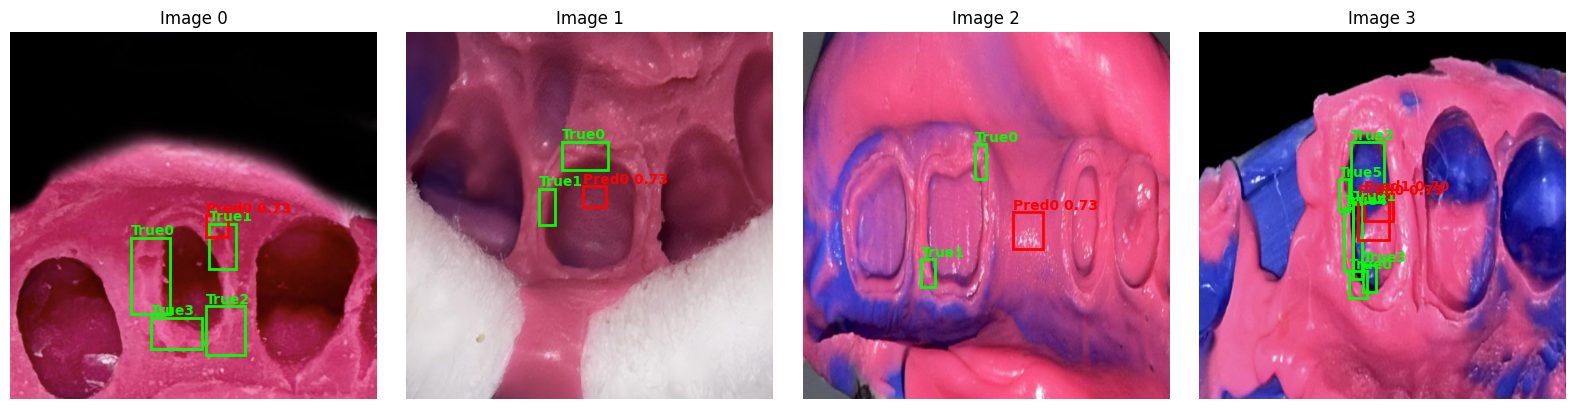

In [11]:
# print 4 images

n_plot = min(4, len(images_np))
fig, axes = plt.subplots(1, n_plot, figsize=(4 * n_plot, 4))
if n_plot == 1: axes = [axes]

for i in range(n_plot):
    ax = axes[i]
    img = images_np[i]
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
    ax.imshow(img_uint8)
    ax.set_title(f"Image {i}")
    ax.axis("off")

    # True boxes (green)
    draw_boxes(ax, img, true_boxes[i], true_classes[i], "lime", "True")

    # Predicted boxes (red)
    draw_boxes(
    ax,
    img,
    pred_boxes[i],
    pred_class[i].reshape(-1),
    "red",
    "Pred",
    scores=pred_class_prob[i].reshape(-1),
    threshold=0.7
)

plt.tight_layout()
plt.show()

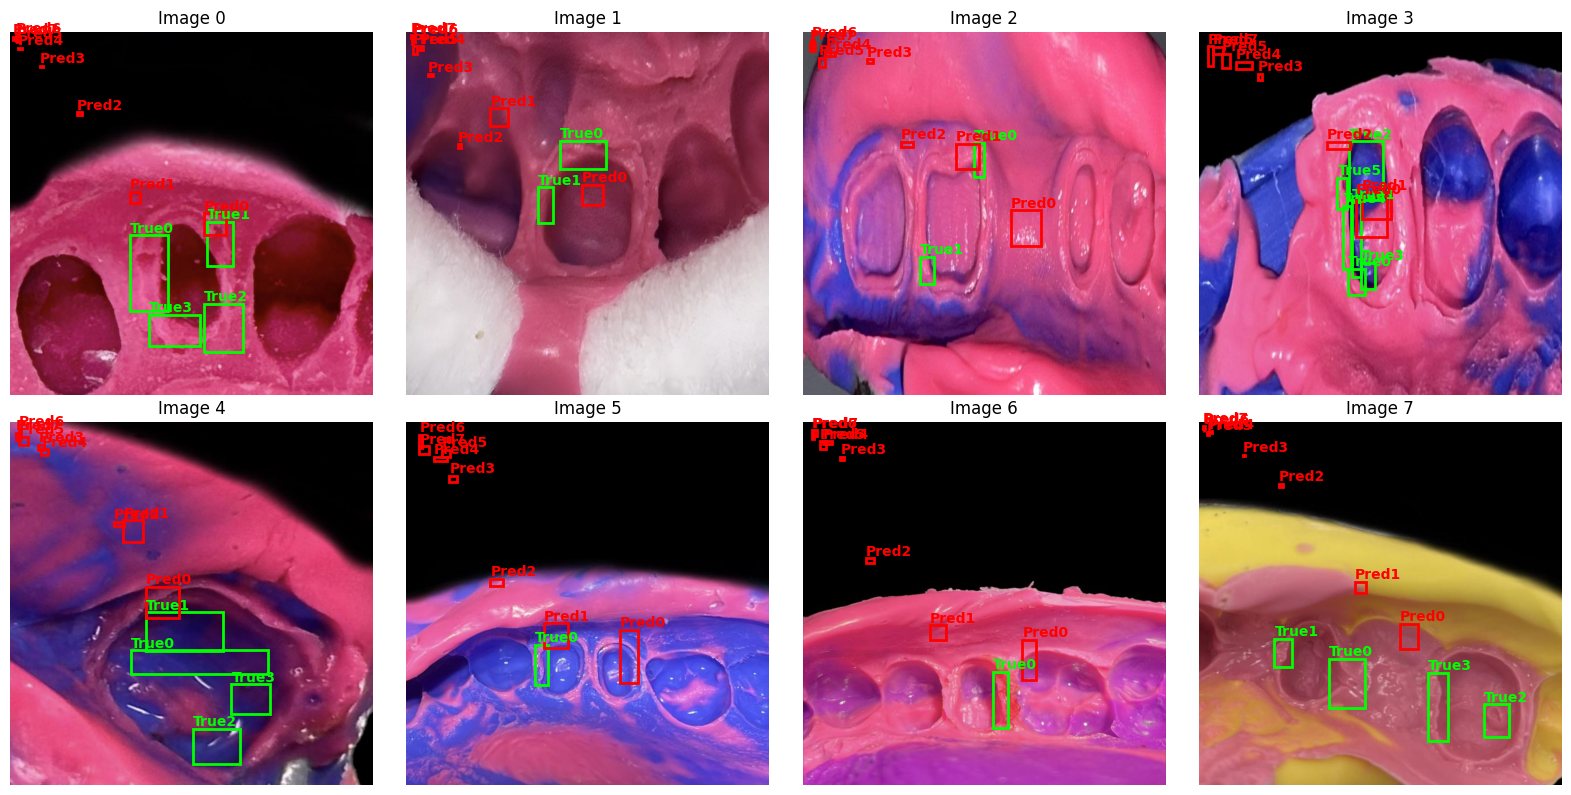

In [12]:
# Print 8 images

# Change: Set n_plot to 8
n_plot = min(8, len(images_np))

# Change: Use a 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten() # Makes it easy to loop through

for i in range(n_plot):
    ax = axes[i]
    img = images_np[i]
    img_uint8 = np.clip(img, 0, 255).astype(np.uint8)
    ax.imshow(img_uint8)
    ax.set_title(f"Image {i}")
    ax.axis("off")

    draw_boxes(ax, img, true_boxes[i], true_classes[i], "lime", "True")
    draw_boxes(ax, img, pred_boxes[i], pred_class[i], "red", "Pred")

# Hide any empty subplots if there are fewer than 8
for i in range(n_plot, 8):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [13]:
def evaluate_model(images, true_boxes_all, true_classes_all, pred_boxes_all, pred_scores_all, threshold=0.5):
    total_matches = []
    tp_count = 0
    fn_count = 0
    total_gt = 0

    for i in range(len(images)):
        # Use our existing matching function
        # Ensure we pass the image to get w, h
        ious = get_matched_ious(
            images[i],
            true_boxes_all[i],
            true_classes_all[i],
            pred_boxes_all[i],
            pred_scores_all[i],
            score_thresh=0.5 # Keep visualization-level threshold or set to 0.5 for evaluation
        )

        # Mean IoU for this image
        total_matches.extend(ious)

        # TP count: detections with IoU >= 0.5
        tp_count += sum(1 for iou in ious if iou >= threshold)

        # Count missed ground truths (FNs)
        # Total GT = true boxes that were actually present
        gt_in_img = sum(1 for c in true_classes_all[i] if int(c) == 1)
        total_gt += gt_in_img

        # FN count: GT boxes - matched detections
        fn_count += (gt_in_img - len(ious))

    mean_iou = np.mean(total_matches) if total_matches else 0

    return {
        "mean_matched_iou": mean_iou,
        "tp_at_0.5": tp_count,
        "fn_count": fn_count
    }

# Run the evaluation
metrics = evaluate_model(images_np, true_boxes, true_classes, pred_boxes, pred_class_prob)
print(f"Metrics: {metrics}")

Metrics: {'mean_matched_iou': np.float64(0.11174764175356217), 'tp_at_0.5': 0, 'fn_count': 54}


/tmp/ipykernel_3204/284282941.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_idx = [j for j in range(len(pred_boxes)) if float(pred_scores[j]) >= score_thresh]


In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 640, 640,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 640, 640,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 20, 20,    │  2,257,984 │ lambda[0][0]      │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      8,224 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │      2,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox (Reshape)      │ (None, 8, 4)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class (Reshape)     │ (None, 8, 1)      │          0 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
x, y = next(iter(val_generator))
pred = model.predict(x)

print(type(pred))
print(len(pred))
print("bbox shape:", pred[0].shape)
print("class shape:", pred[1].shape)
print("First bbox sample:", pred[0][0])
print("First class sample:", pred[1][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
<class 'list'>
2
bbox shape: (21, 8, 4)
class shape: (21, 8, 1)
First bbox sample: [[0.5342301  0.49872747 0.06037319 0.05997093]
 [0.33042943 0.43978885 0.02603989 0.03108644]
 [0.18277682 0.2198473  0.01351776 0.00758198]
 [0.08234344 0.09136077 0.00735672 0.00260252]
 [0.02098374 0.04192328 0.0115103  0.00252734]
 [0.01905744 0.02144744 0.00763873 0.00632767]
 [0.01601955 0.00561918 0.00135828 0.01724653]
 [0.00693041 0.01141988 0.00630131 0.00861589]]
First class sample: [[0.99952227]
 [0.7186755 ]
 [0.7199992 ]
 [0.23650742]
 [0.14944357]
 [0.0422057 ]
 [0.01248643]
 [0.0105841 ]]
